In [ ]:
#!pip uninstall -y jax jaxlib
#!pip install --upgrade jax jaxlib

In [ ]:
#!pip install --quiet tensorflow-datasets

# CNN para la clasificación de imágenes en Keras: para clasificar imágenes de perros y gatos

El dataset Cats vs Dogs es un conjunto de imágenes utilizado para tareas de clasificación binaria en visión por computador. Fue originalmente publicado por Microsoft Research como parte del reto Asirra (Animal Species Image Recognition for Restricting Access) y más tarde adaptado para la competencia de Kaggle Dogs vs. Cats.

Características del dataset.

Número total de imágenes: 25,000 aproximadamente.

Clases: 2 0: gato  1: perro

Formato: imágenes en color (RGB) en formato .jpg

Tamaño de las imágenes: variable, generalmente entre 200×200 y 500×500 píxeles.

Etiquetado: supervisado; cada imagen viene con su categoría.

Fuente: Microsoft Research y Kaggle.

Versión procesada por TensorFlow Datasets:
Excluye 1,738 imágenes dañadas del original.  Conserva 23,262 imágenes limpias.

Disponible en tensorflow_datasets con el nombre 'cats_vs_dogs': https://www.tensorflow.org/datasets/catalog/cats_vs_dogs?hl=es-419

In [ ]:
from tensorflow.keras import backend as K
# Evitar residuos de modelos anteriores (Liberar memoria en la GPU/CPU)
K.clear_session()

In [ ]:
#XLA (Accelerated Linear Algebra) es un compilador just-in-time (JIT) de TensorFlow que optimiza automáticamente operaciones matemáticas para mejorar el rendimiento, especialmente en GPU o TPU.
import os
os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"  #le dice a TensorFlow que no use XLA, incluso si está disponible.
#en el caso de que el entrenamiento o inferencia se vuelve más lento al activar XLA.

In [ ]:
import tensorflow_datasets as tfds

# Cargar el dataset con etiquetas
# split='train' indica que solo usamos la partición de entrenamiento
# as_supervised=True indica que se cargan las imágenes junto con sus etiquetas (imagen, etiqueta)
# with_info=True permite acceder a información adicional del dataset (ds_info)
(ds, ds_info) = tfds.load('cats_vs_dogs', split='train', as_supervised=True, with_info=True)

# Mostrar una descripción general del dataset cargado
print("Descripción del dataset:")
print(ds_info.description)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.UTZ6FY_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Descripción del dataset:
A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.


In [ ]:
# Mostrar número total de imágenes y las etiquetas disponibles
print("\nNúmero de ejemplos:", ds_info.splits['train'].num_examples)
print("Etiquetas:", ds_info.features['label'].names)


Número de ejemplos: 23262
Etiquetas: ['cat', 'dog']


In [ ]:
import psutil

mem = psutil.virtual_memory()
print(f"Memoria disponible: {mem.available / 1e9:.2f} GB")
print(f"Memoria usada:      {mem.used / 1e9:.2f} GB")
print(f"Memoria total:      {mem.total / 1e9:.2f} GB")


Memoria disponible: 11.83 GB
Memoria usada:      1.43 GB
Memoria total:      13.61 GB


In [ ]:
total_gatos = 0
total_perros = 0

for _, etiqueta in ds:
    clase = int(etiqueta.numpy())
    if clase == 0:
        total_gatos += 1
    else:
        total_perros += 1

print(f"Gatos: {total_gatos}")
print(f"Perros: {total_perros}")


Gatos: 11658
Perros: 11604


In [ ]:
import psutil

mem = psutil.virtual_memory()
print(f"Memoria disponible: {mem.available / 1e9:.2f} GB")
print(f"Memoria usada:      {mem.used / 1e9:.2f} GB")
print(f"Memoria total:      {mem.total / 1e9:.2f} GB")


Memoria disponible: 11.71 GB
Memoria usada:      1.55 GB
Memoria total:      13.61 GB


In [ ]:
total_gatos = ds_info.splits['train'].num_examples // 2
total_perros = ds_info.splits['train'].num_examples - total_gatos

In [ ]:
import tensorflow as tf

In [ ]:
gato = next(ds.filter(lambda img, lbl: tf.equal(lbl,0)).take(1).map(lambda img,_:img).as_numpy_iterator())
perro = next(ds.filter(lambda img, lbl: tf.equal(lbl,1)).take(1).map(lambda img,_:img).as_numpy_iterator())

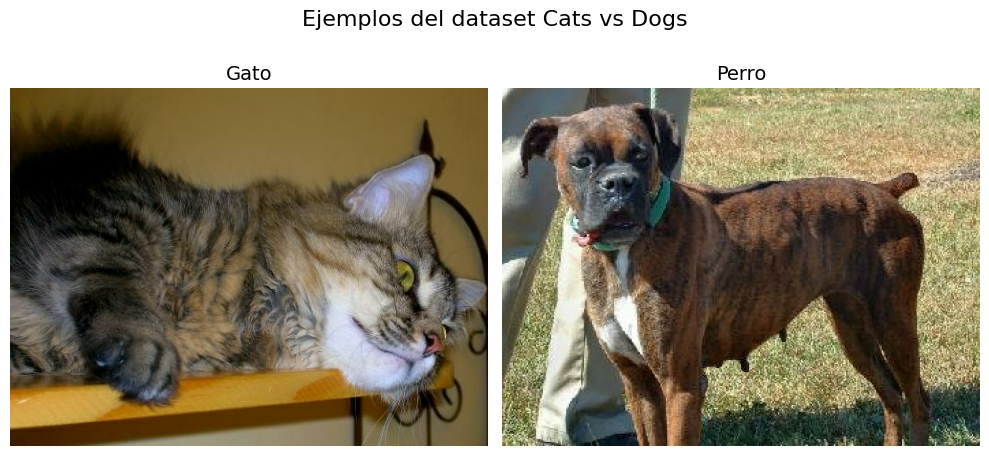

In [ ]:
import matplotlib.pyplot as plt

# Variables para guardar una imagen de gato y una de perro
imagen_gato = None
imagen_perro = None

# Recorrer el dataset hasta encontrar una imagen de cada clase
for imagen, etiqueta in ds:
    if etiqueta.numpy() == 0 and imagen_gato is None:
        imagen_gato = imagen
    elif etiqueta.numpy() == 1 and imagen_perro is None:
        imagen_perro = imagen
    if imagen_gato is not None and imagen_perro is not None:
        break  # Salir del ciclo cuando se hayan encontrado ambas

# Mostrar ambas imágenes en una visualización tipo subplot
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(imagen_gato)
axs[0].set_title("Gato", fontsize=14)
axs[0].axis("off")

axs[1].imshow(imagen_perro)
axs[1].set_title("Perro", fontsize=14)
axs[1].axis("off")

plt.suptitle("Ejemplos del dataset Cats vs Dogs", fontsize=16)
plt.tight_layout()
plt.show()


Aumento de datos (Data Augmentation)
El objetivo del aumento de datos es ampliar el conjunto de datos de entrenamiento aplicando diferentes transformaciones a las imágenes originales.
Estas transformaciones incluyen: rotaciones, traslaciones, escalado, entre otras.
Esto se hace mediante la clase ImageDataGenerator.

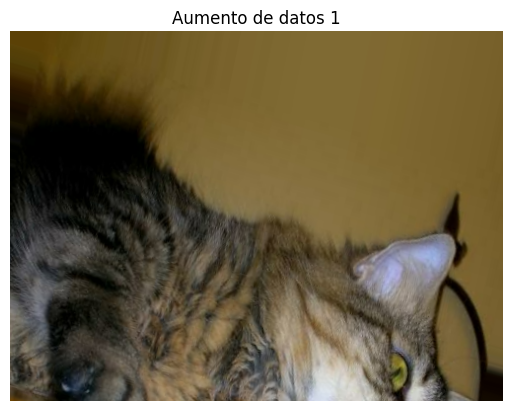

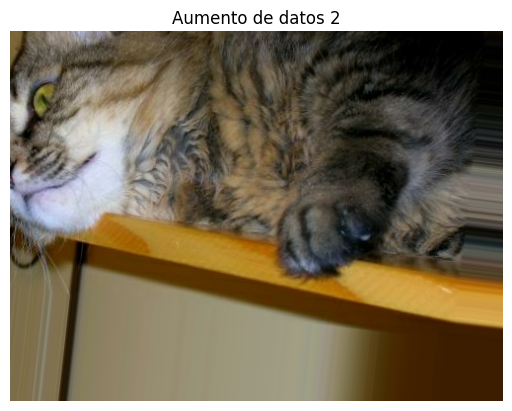

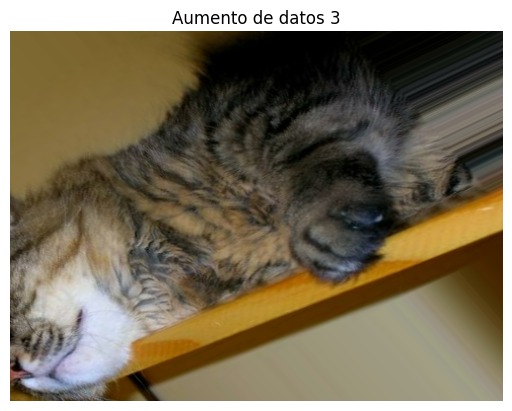

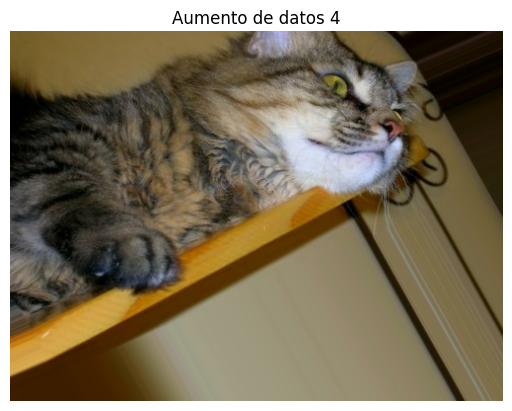

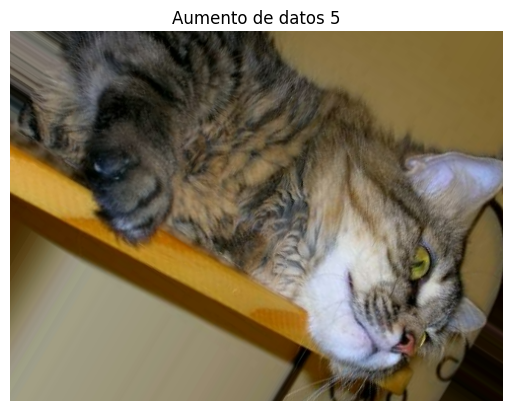

In [ ]:
# Importar herramientas de procesamiento de imágenes de Keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array

# Buscar una imagen de gato del dataset
for imagen, etiqueta in ds:
    if etiqueta.numpy() == 0:  # 0 representa "gato"
        imagen_gato = imagen
        break

# Convertir la imagen de tensor a array NumPy y ajustar forma para el generador
x = img_to_array(imagen_gato)  # Convierte la imagen a array NumPy (alto, ancho, canales)
x = x.reshape((1,) + x.shape)  # Añade dimensión para lote: (1, alto, ancho, canales)

# Definir el generador para aumento de datos (data augmentation)
datagen = ImageDataGenerator(
    rotation_range=40,         # Rango de rotación aleatoria (grados)
    width_shift_range=0.2,     # Desplazamiento horizontal (proporcional al ancho)
    height_shift_range=0.2,    # Desplazamiento vertical (proporcional a la altura)
    shear_range=0.2,           # Cizallamiento (distorsión angular)
    zoom_range=0.2,            # Zoom aleatorio dentro del rango
    horizontal_flip=True,      # Volteo horizontal aleatorio
    fill_mode='nearest'        # Cómo rellenar los píxeles vacíos tras transformación
)

# Visualizar 5 imágenes aumentadas generadas a partir de la original
i = 0
for lote in datagen.flow(x, batch_size=1):
    i += 1
    plt.imshow(lote[0].astype('uint8'))  # Convertir imagen a valores válidos para mostrar
    plt.title(f"Aumento de datos {i}")
    plt.axis("off")
    plt.show()
    if i >= 5:
        break  # Solo mostrar 5 ejemplos


**Configuración de hiperparámetros y preparación del conjunto de datos**

División del dataset y preprocesamiento

In [ ]:

# Obtener el número total de muestras del dataset original
total_muestras = ds_info.splits['train'].num_examples
print("Total de imágenes en el dataset:", total_muestras)

Total de imágenes en el dataset: 23262


In [ ]:
tam_buffer = 1000
ds_shuf = ds.shuffle(buffer_size=tam_buffer, seed=42)

#ds_shuf = ds.shuffle(buffer_size=total_muestras, seed=42)
# Partición primero
#tam_ent = int(0.5 * total_muestras)
#ds_train_full = ds_shuf.take(tam_ent)
#ds_val_full = ds_shuf.skip(tam_ent)

# una parte para debug
(ds_train_full, ds_val_full), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:50%]', 'train[50%:]'],
    as_supervised=True,
    with_info=True,
    shuffle_files=True
)

ds_train = ds_train_full.take(2000)
ds_val   = ds_val_full.take(500)

In [ ]:
print("Tamaño del conjunto de entrenamiento:", tf.data.experimental.cardinality(ds_train).numpy())
print("Tamaño del conjunto de validación:", tf.data.experimental.cardinality(ds_val).numpy())

Tamaño del conjunto de entrenamiento: 2000
Tamaño del conjunto de validación: 500


In [ ]:
# Definición de hiperparámetros
ancho_img, alto_img = 150, 150   # Dimensiones objetivo de las imágenes
tam_lote = 8

In [ ]:
# Función de preprocesamiento sin aumento (para validación o prueba)
def preprocesar_sin_aumento(imagen, etiqueta):
    imagen = tf.image.resize(imagen, [alto_img, ancho_img])   # Redimensionar la imagen
    imagen = tf.cast(imagen, tf.float32) / 255.0              # Normalizar a rango [0, 1]
    return imagen, etiqueta

# Función de preprocesamiento con aumento de datos (solo para entrenamiento)
def preprocesar_con_aumento(imagen, etiqueta):
    imagen = tf.image.resize(imagen, [alto_img, ancho_img])
    imagen = tf.cast(imagen, tf.float32) / 255.0
    imagen = tf.image.random_flip_left_right(imagen)           # Volteo horizontal aleatorio
    imagen = tf.image.random_brightness(imagen, max_delta=0.2) # Variación aleatoria del brillo
    return imagen, etiqueta

In [ ]:
#Preparación del dataset
# Pipeline de datos optimizado
#Aplicar funciones de preprocesamiento, agrupar en lotes (batch) y optimizar lectura
AUTOTUNE = tf.data.AUTOTUNE

# Conjunto de entrenamiento:
# - Se aplica aumento de datos (rotación, brillo)
# - Se agrupan en lotes
# - Se prefetch (carga anticipada) para optimizar rendimiento
ds_entrenamiento = (
    ds_train
    .shuffle(tam_buffer)
    .map(preprocesar_con_aumento, num_parallel_calls=AUTOTUNE)
    .batch(tam_lote)
    .prefetch(AUTOTUNE)
)

# Conjunto de validación:
# - Solo se redimensiona y normaliza (sin aumentos)
# - También se agrupan y se aplica prefetch
ds_validacion = (
    ds_val
    .map(preprocesar_sin_aumento, num_parallel_calls=AUTOTUNE)
    .batch(tam_lote)
    .prefetch(AUTOTUNE)
)

**Modelo de la CNN**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras import backend as K

# Definir la forma de entrada según el formato de imagen del backend
# Algunos sistemas usan 'channels_first' (canales primero), otros 'channels_last'
if K.image_data_format() == 'channels_first':
    forma_entrada = (3, alto_img, ancho_img)  # (canales, alto, ancho)
else:
    forma_entrada = (alto_img, ancho_img, 3)  # (alto, ancho, canales)

# Definición del modelo secuencial de red neuronal convolucional (CNN)
modelo = Sequential()

# Primera capa convolucional + activación ReLU + max-pooling
modelo.add(Conv2D(32, (3, 3), input_shape=forma_entrada))
modelo.add(Activation('relu'))
modelo.add(MaxPooling2D(pool_size=(2, 2)))

# Segunda capa convolucional + activación + pooling
modelo.add(Conv2D(32, (3, 3)))
modelo.add(Activation('relu'))
modelo.add(MaxPooling2D(pool_size=(2, 2)))

# Tercera capa convolucional + activación + pooling
modelo.add(Conv2D(64, (3, 3)))
modelo.add(Activation('relu'))
modelo.add(MaxPooling2D(pool_size=(2, 2)))

# Aplanar las características extraídas
modelo.add(Flatten())

# Capa densa intermedia
modelo.add(Dense(64))
modelo.add(Activation('relu'))
modelo.add(Dropout(0.5))  # Dropout para evitar sobreajuste

# Capa de salida (1 neurona con activación sigmoide para clasificación binaria)
modelo.add(Dense(1))
modelo.add(Activation('sigmoid'))

# Mostrar la arquitectura del modelo
modelo.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 148, 148, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 72, 72, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,183,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,212,513 (4.63 MB)

 Trainable params: 1,212,513 (4.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import gc
import tensorflow.keras.backend as K
# Libera modelo anterior
K.clear_session()
# Fuerza recolección de basura
gc.collect()

0

In [ ]:
# Compilación del modelo antes del entrenamiento
modelo.compile(
    loss='binary_crossentropy',     # Función de pérdida para clasificación binaria
    optimizer='rmsprop',            # Optimizador (puedes usar también 'adam')
    metrics=['accuracy']            # Métrica a monitorizar durante el entrenamiento
)

In [ ]:
import psutil

mem = psutil.virtual_memory()
print(f"Memoria disponible: {mem.available / 1e9:.2f} GB")
print(f"Memoria usada:      {mem.used / 1e9:.2f} GB")
print(f"Memoria total:      {mem.total / 1e9:.2f} GB")


Memoria disponible: 11.88 GB
Memoria usada:      1.38 GB
Memoria total:      13.61 GB


In [ ]:
  # Entrenamiento del modelo
historial = modelo.fit(
    ds_entrenamiento,          # Conjunto de entrenamiento con aumentos de datos
    epochs=20,                 # Número de épocas (pasadas completas por los datos)
    validation_data=ds_validacion  # Conjunto de validación (sin aumento)
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.5014 - loss: 0.7127 - val_accuracy: 0.5160 - val_loss: 0.6917
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5764 - loss: 0.6889 - val_accuracy: 0.6600 - val_loss: 0.6561
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.6424 - loss: 0.6444 - val_accuracy: 0.6560 - val_loss: 0.6183
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6687 - loss: 0.6198 - val_accuracy: 0.7000 - val_loss: 0.5957
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7125 - loss: 0.5686 - val_accuracy: 0.7180 - val_loss: 0.5595
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7204 - loss: 0.5702 - val_accuracy: 0.6900 - val_loss: 0.6441
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7421 - loss: 0.5326 - val_accuracy: 0.7460 - val_loss: 0.5479
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7840 - loss: 0.4986 - val_acc

In [ ]:
import psutil

mem = psutil.virtual_memory()
print(f"Memoria disponible: {mem.available / 1e9:.2f} GB")
print(f"Memoria usada:      {mem.used / 1e9:.2f} GB")
print(f"Memoria total:      {mem.total / 1e9:.2f} GB")


Memoria disponible: 10.54 GB
Memoria usada:      2.68 GB
Memoria total:      13.61 GB


In [ ]:
loss, acc = modelo.evaluate(ds_validacion)
print("Pérdida:", loss)
print("Precisión:", acc)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7171 - loss: 0.9535
Pérdida: 0.8457559943199158
Precisión: 0.7400000095367432


In [ ]:
# Mostrar las claves del historial de entrenamiento
print(historial.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


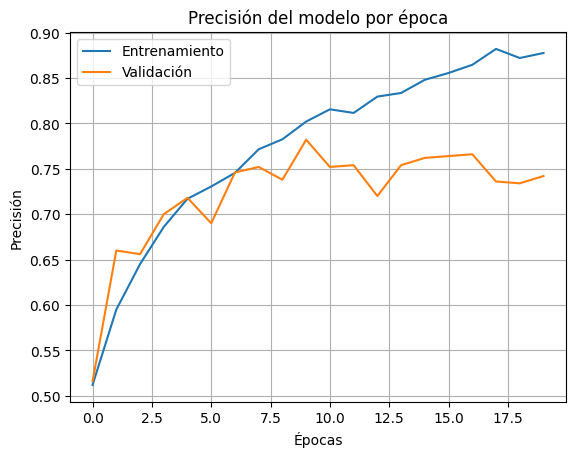

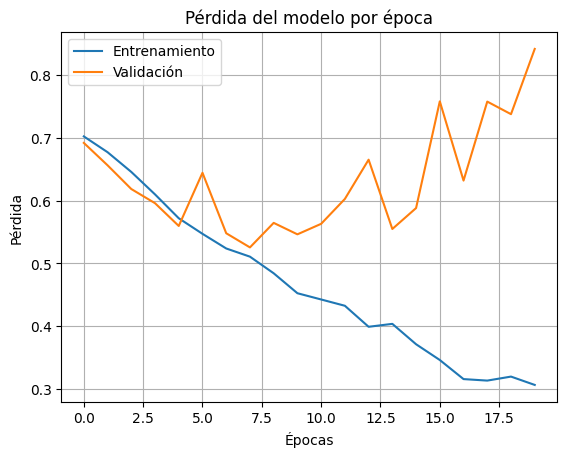

In [ ]:
import matplotlib.pyplot as plt

# Gráfica de precisión (accuracy)
plt.plot(historial.history['accuracy'], label='Entrenamiento')
if 'val_accuracy' in historial.history:
    plt.plot(historial.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo por época')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)
plt.show()

# Gráfica de pérdida (loss)
plt.plot(historial.history['loss'], label='Entrenamiento')
if 'val_loss' in historial.history:
    plt.plot(historial.history['val_loss'], label='Validación')
plt.title('Pérdida del modelo por época')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Mostrar las GPUs disponibles
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detectada: {gpus[0].name}")
else:
    print("No se detectó GPU. Se usará CPU.")


GPU detectada: /physical_device:GPU:0


In [ ]:
from tensorflow.python.client import device_lib
# Muestra toda la información técnica detallada sobre cada dispositivo
# Mostrar los dispositivos disponibles (CPU, GPU, etc.)
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 16138537244064778271
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14619377664
locality {
  bus_id: 1
  links {
  }
}
incarnation: 7992429448173335588
physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
xla_global_id: 416903419
]


In [ ]:
!nvidia-smi

Thu Oct 30 13:44:55 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   70C    P0             39W /   70W |     634MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Prueba del clasificador

In [ ]:
for sample in ds_validacion.take(1):
    print(sample)

(<tf.Tensor: shape=(8, 150, 150, 3), dtype=float32, numpy=
array([[[[8.56078416e-02, 7.58039206e-02, 1.04313716e-02],
         [4.33620930e-01, 4.14013088e-01, 2.78928101e-01],
         [5.14352977e-01, 4.88862753e-01, 2.92784333e-01],
         ...,
         [2.24862739e-01, 1.85647056e-01, 1.17019609e-01],
         [2.15150326e-01, 1.58496723e-01, 8.39869231e-02],
         [2.74679750e-01, 2.12352946e-01, 1.31751627e-01]],

        [[2.13725477e-01, 2.03294098e-01, 1.25647053e-01],
         [3.09647083e-01, 2.86784321e-01, 1.73568636e-01],
         [5.23568630e-01, 4.96117651e-01, 3.03960800e-01],
         ...,
         [2.12470591e-01, 1.78431377e-01, 1.12392157e-01],
         [2.10549027e-01, 1.69960782e-01, 9.34901983e-02],
         [2.08156869e-01, 1.62352949e-01, 8.52549076e-02]],

        [[3.66993457e-01, 3.54771227e-01, 2.28104562e-01],
         [1.86993465e-01, 1.61503270e-01, 8.32026228e-02],
         [5.24117649e-01, 4.98627454e-01, 3.17320257e-01],
         ...,
         [

In [ ]:
for image, label in ds_validacion.take(1):
    print(image.shape, label)

(8, 150, 150, 3) tf.Tensor([0 1 0 1 0 0 0 0], shape=(8,), dtype=int64)


In [ ]:
# Diagnóstico: verificar que el conjunto no esté vacío
for imagen, etiqueta in ds_validacion.take(1):
    print("Imagen shape:", imagen.shape)
    print("Etiqueta:", etiqueta.numpy())
    break

Imagen shape: (8, 150, 150, 3)
Etiqueta: [0 1 1 1 1 1 1 1]


In [ ]:
# ds_val = subconjunto de validación

# Hiperparámetros coherentes
ancho_img, alto_img = 150, 150
tam_lote = 16

# Función de preprocesamiento sin aumentos (validación)
def preprocesar_sin_aumento(imagen, etiqueta):
    imagen = tf.image.resize(imagen, [alto_img, ancho_img])
    imagen = tf.cast(imagen, tf.float32) / 255.0
    return imagen, etiqueta

# Crear dataset de validación funcional
ds_validacion = ds_val.map(preprocesar_sin_aumento).batch(tam_lote).prefetch(tf.data.AUTOTUNE)


Batch obtenido: (16, 150, 150, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
Real: Perro | Predicho: Gato


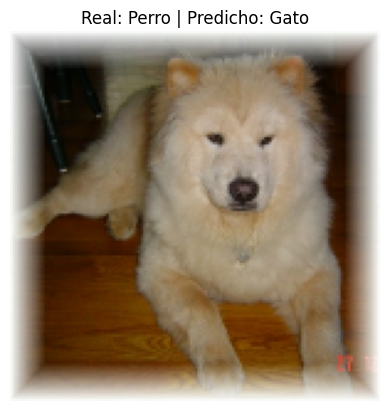

In [ ]:
for x_batch, y_batch in ds_validacion.take(1):
    print("Batch obtenido:", x_batch.shape)

    plt.imshow(x_batch[0])
    plt.axis("off")

    pred = modelo.predict(x_batch)
    etiqueta_real = y_batch[0].numpy()
    clase_real = "Perro" if etiqueta_real == 1 else "Gato"
    clase_predicha = "Perro" if pred[0][0] >= 0.5 else "Gato"

    print("Real:", clase_real, "| Predicho:", clase_predicha)
    plt.title(f"Real: {clase_real} | Predicho: {clase_predicha}")
    plt.show()
    break


In [ ]:
print("Pred shape:", pred.shape)


Pred shape: (16, 1)


Forma de la imagen: (150, 150, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Etiqueta real: Gato
Probabilidad predicha: 0.0026973367
Clase predicha: Gato


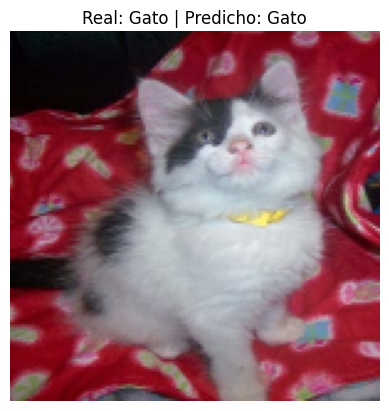

In [ ]:
import matplotlib.pyplot as plt

# Tomar un solo lote del conjunto de validación
for x_batch, y_batch in ds_validacion.take(1):  # Solo un batch
    print("Forma de la imagen:", x_batch[0].shape)  # Verifica las dimensiones (150x150x3)

    # Mostrar la imagen
    plt.imshow(x_batch[0])
    plt.axis("off")

    # Hacer predicción sobre el lote
    pred = modelo.predict(x_batch)

    # Obtener etiqueta real y traducir a texto
    etiqueta_real = y_batch[0].numpy()
    clase_real = "Perro" if etiqueta_real == 1 else "Gato"

    # Interpretar la predicción (probabilidad > 0.5 → Perro)
    clase_predicha = "Perro" if pred[0][0] >= 0.5 else "Gato"

    # Mostrar resultados
    print("Etiqueta real:", clase_real)
    print("Probabilidad predicha:", pred[0][0])
    print("Clase predicha:", clase_predicha)

    # Título en la imagen
    plt.title(f"Real: {clase_real} | Predicho: {clase_predicha}")
    plt.show()
    break


In [ ]:
modelo.evaluate(ds_validacion)


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7542 - loss: 0.8471


[0.8388903141021729, 0.7459999918937683]

Aprendizaje por transferencia

Utilizaremos un modelo de clasificación de imágenes preentrenado de Keras. Está documentado [aquí](https://keras.io/applications/)

In [ ]:
# Importar componentes necesarios de Keras
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras import Input

# Cargar el modelo base MobileNet SIN la capa superior (fully connected)
# - include_top=False → omite la última capa densa de clasificación
# - weights='imagenet' → usa pesos preentrenados en el dataset ImageNet
# - input_shape → define la forma de entrada que usará nuestro dataset
base_model = MobileNet(
    include_top=False,
    weights='imagenet',
    input_shape=(alto_img, ancho_img, 3)
)

# Congelar los pesos del modelo base → no se entrenan durante fine-tuning inicial
base_model.trainable = False

# Crear modelo secuencial agregando el modelo base + capas propias encima
modelo1 = Sequential([
    Input(shape=(ancho_img, alto_img, 3)),  # capa de entrada explícita
    base_model,                               # cuerpo convolucional de MobileNet
    Flatten(),                                # aplanar las salidas convolucionales
    Dense(64, activation='relu'),             # capa densa intermedia
    Dropout(0.5),                              # para evitar sobreajuste
    Dense(1, activation='sigmoid')            # salida binaria (perro/gato)
])

# Compilar el modelo
modelo1.compile(
    loss='binary_crossentropy',    # función de pérdida para clasificación binaria
    optimizer='adam',              # optimizador moderno y eficiente
    metrics=['accuracy']           # métrica a monitorear
)

# Entrenamiento con datasets formateados con tf.data
# - ds_train_aug: conjunto de entrenamiento con aumentos de datos
# - ds_val_clean: conjunto de validación sin aumentos
modelo1.fit(
    ds_entrenamiento,
    validation_data=ds_validacion,
    epochs=10
)


/tmp/ipython-input-3734669623.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 31s 76ms/step - accuracy: 0.8604 - loss: 0.9273 - val_accuracy: 0.9660 - val_loss: 0.0876
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9204 - loss: 0.2061 - val_accuracy: 0.9700 - val_loss: 0.0655
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9402 - loss: 0.1430 - val_accuracy: 0.9740 - val_loss: 0.0587
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9480 - loss: 0.1133 - val_accuracy: 0.9820 - val_loss: 0.0762
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9472 - loss: 0.0974 - val_accuracy: 0.9800 - val_loss: 0.0575
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9634 - loss: 0.0879 - val_accuracy: 0.9720 - val_loss: 0.0888
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9612 - loss: 0.0820 - val_accuracy: 0.9740 - val_loss: 0.0622
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 12

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout

# Construcción del modelo completo "modelo1", añadiendo una cabeza de clasificación
modelo1 = Sequential([
    # Capa de entrada: define la forma de las imágenes que recibirá el modelo
    Input(shape=(alto_img, ancho_img, 3)),  # (alto, ancho, canales RGB)

    # Modelo base preentrenado (por ejemplo MobileNet sin la parte superior)
    #    Extrae características avanzadas de la imagen
    base_model,

    # GlobalAveragePooling2D:
    #    Para cada mapa de características 2D de salida del modelo base (h × w × c),
    #    calcula el promedio espacial a lo largo de h y w.
    #    Resultado: un vector de longitud c (reduce drásticamente parámetros).
    GlobalAveragePooling2D(),

    # Capa densa intermedia:
    #    Aprende combinaciones no lineales de las características extraídas.
    Dense(64, activation='relu'),

    # Dropout:
    #    Durante el entrenamiento, desactiva aleatoriamente el 50 % de neuronas
    #    para evitar que el modelo dependa demasiado de rutas particulares
    Dropout(0.5),

    # Capa de salida:
    #    Una única neurona con activación sigmoide, ideal para clasificación binaria.
    Dense(1, activation='sigmoid')
])


In [ ]:
modelo1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 4, 4, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,294,529 (12.57 MB)

 Trainable params: 65,665 (256.50 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Etiqueta real: 1
Probabilidad de 'perro': 0.9991303


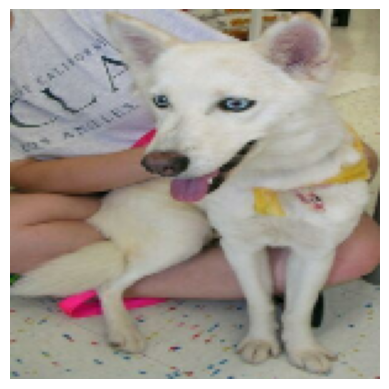

In [ ]:
import matplotlib.pyplot as plt  # Librería para visualización de imágenes y gráficos

# Tomamos un único lote de validación (x_batch: imágenes, y_batch: etiquetas)
for x_batch, y_batch in ds_validacion.take(1):
    # Mostrar la primera imagen del lote
    plt.imshow(x_batch[0])
    plt.axis('off')             # Oculta ejes (solo mostramos la imagen)

    #  Hacer predicción sobre esa misma imagen
    #    modelo1.predict espera un lote, por eso pasamos x_batch[:1]
    pred = modelo1.predict(x_batch[:1])

    #  Imprimir la etiqueta real (0=gato, 1=perro)
    print("Etiqueta real:", int(y_batch[0].numpy()))

    # imprimir la probabilidad de que sea 'perro'
    #    pred[0][0] extrae el primer valor de la salida sigmoide
    print("Probabilidad de 'perro':", pred[0][0])

    break  # Salimos después de procesar la primera imagen
